Dataset Loaded Successfully!

First 5 Rows:
  iso3c      Country  Rank     Score  Incidents  Fatalities  Injuries  \
0   IRQ         Iraq     1  9.599967       1288        2086      5050   
1   PAK     Pakistan     2  9.152620        638        1322      2297   
2   AFG  Afghanistan     3  9.134265        507        1511      2612   
3   SYR        Syria     4  8.238079        168        1014      1833   
4   YEM        Yemen     5  8.098513        219         651       798   

   Hostages  Year  
0        16  2012  
1       160  2012  
2        67  2012  
3        71  2012  
4       121  2012  

Dataset Shape:
(1793, 9)

Column Names:
['iso3c', 'Country', 'Rank', 'Score', 'Incidents', 'Fatalities', 'Injuries', 'Hostages', 'Year']

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1793 entries, 0 to 1792
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   iso3c       1793 non-null   object 
 1   Cou

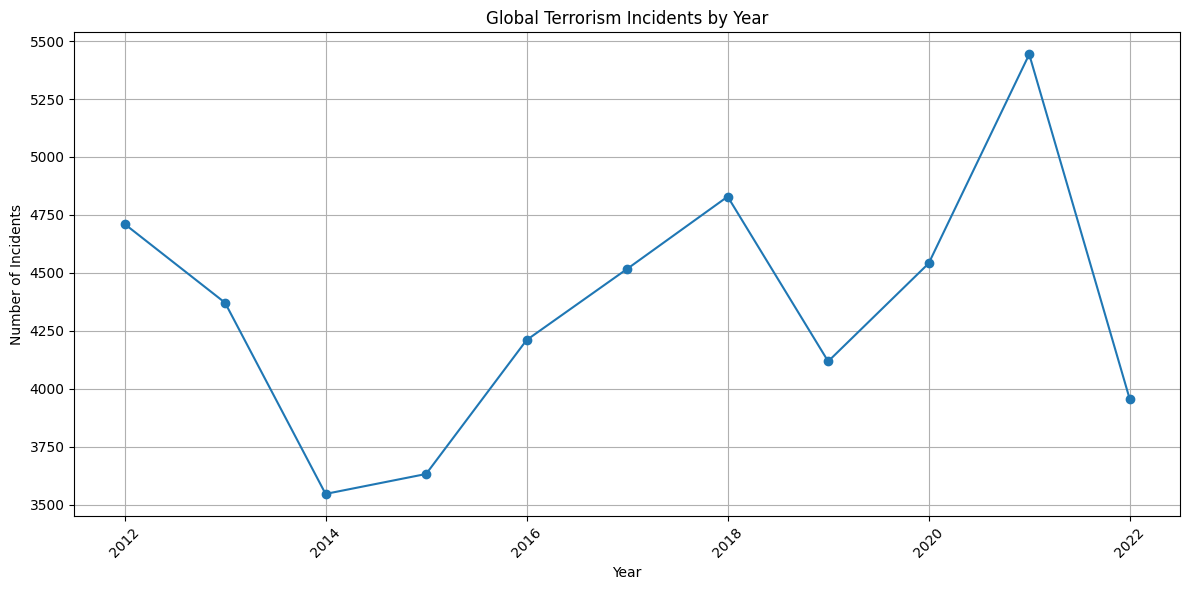

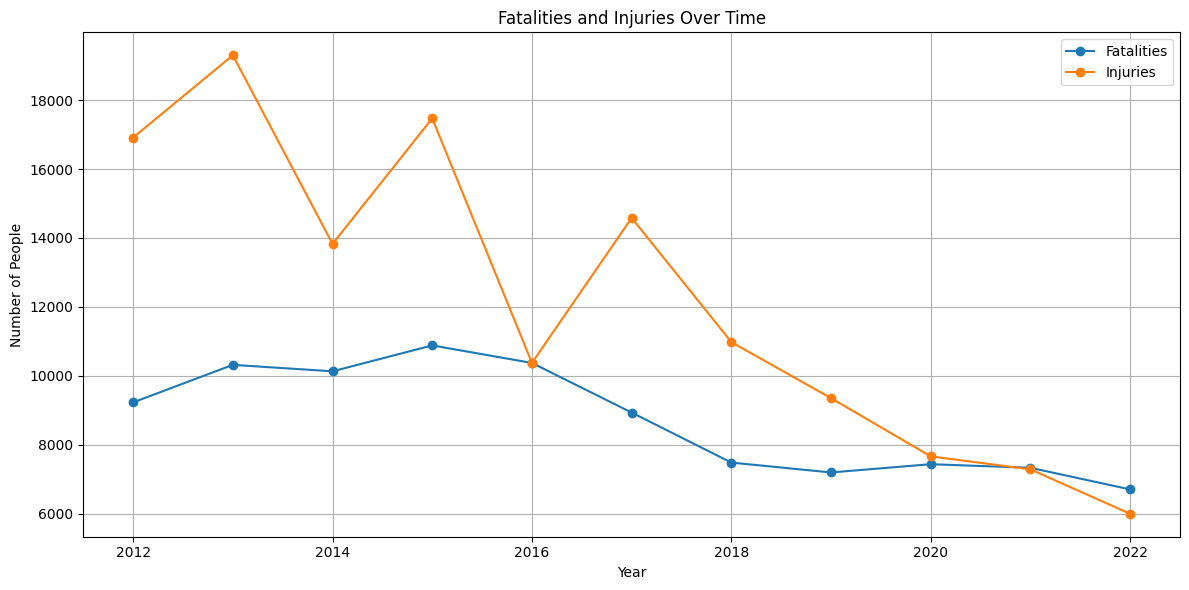


Top 10 Countries by Incidents:
country
Iraq           11183
Afghanistan     4443
Pakistan        3358
Somalia         2951
India           2872
Nigeria         1718
Colombia        1716
Mali            1636
Myanmar         1575
Syria           1551
Name: incidents, dtype: int64


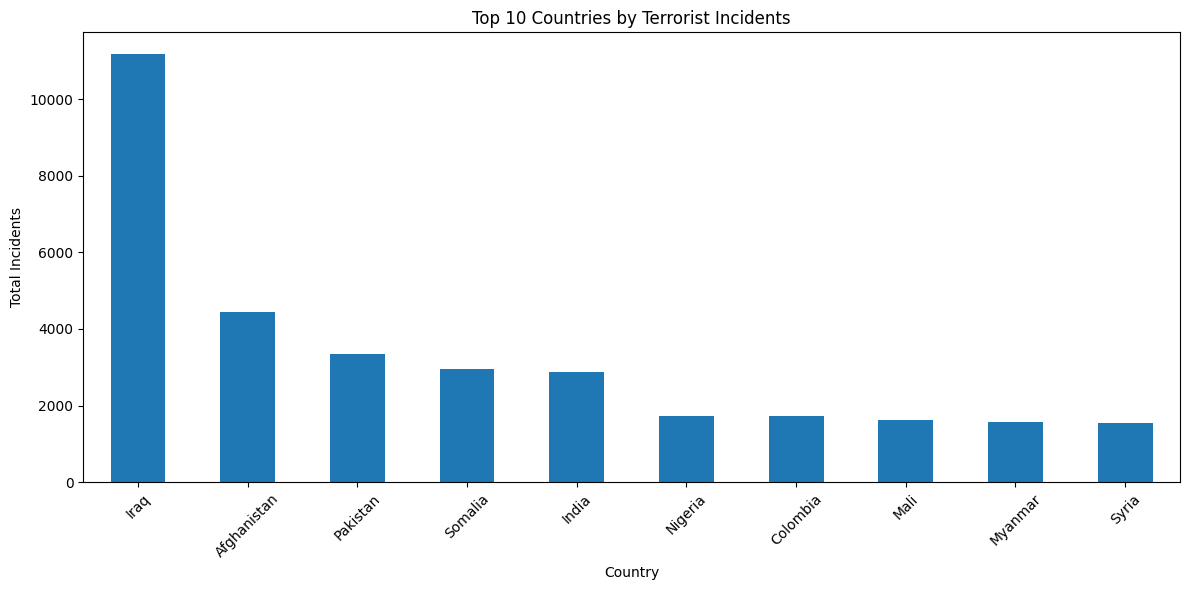


Top 10 Countries by Fatalities:
country
Iraq            21286
Afghanistan     12726
Nigeria         10191
Pakistan         7692
Somalia          7209
Syria            5977
Burkina Faso     3515
Mali             3428
Yemen            2547
Egypt            2494
Name: fatalities, dtype: int64


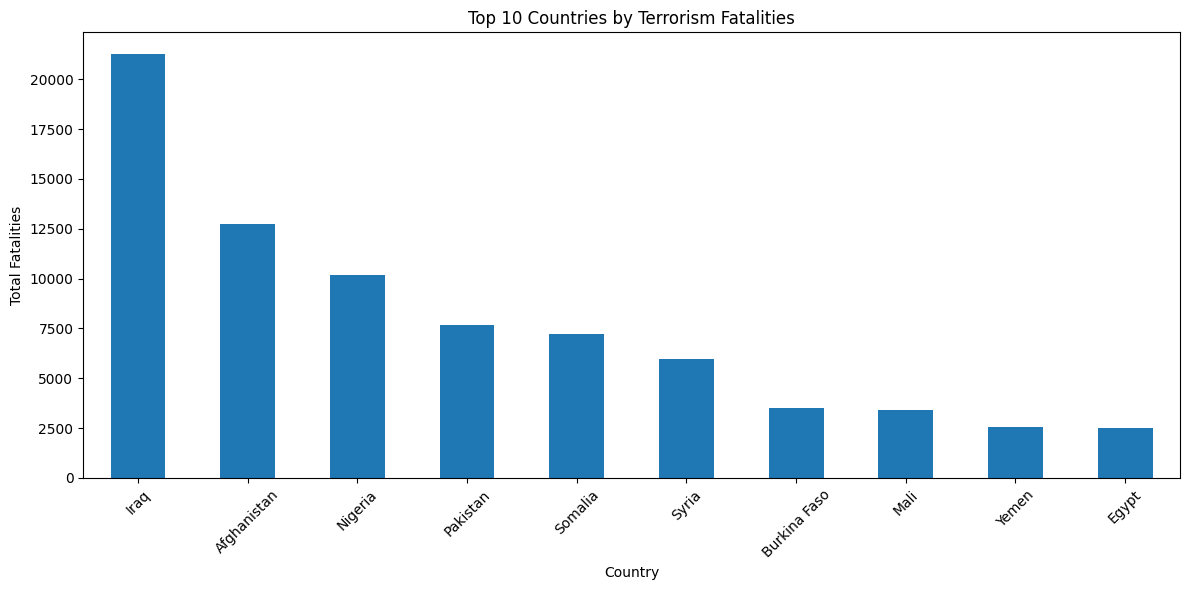


Top 10 Countries by Injuries:
country
Iraq           38381
Afghanistan    21263
Pakistan       14060
Syria           8131
Somalia         6740
Nigeria         6089
India           3048
Yemen           2992
Egypt           2914
Mali            2871
Name: injuries, dtype: int64

Countries with Highest Fatality Rate:
                              country  incidents  fatalities  injuries  \
102                       New Zealand          2          51        55   
135                         Sri Lanka         16         199       133   
76                             Kuwait          3          27       227   
26                               Chad         64         542       668   
141                        Tajikistan          8          67        13   
28                              China         29         232       511   
36   Democratic Republic of the Congo         95         566       142   
105                           Nigeria       1718       10191      6089   
103              

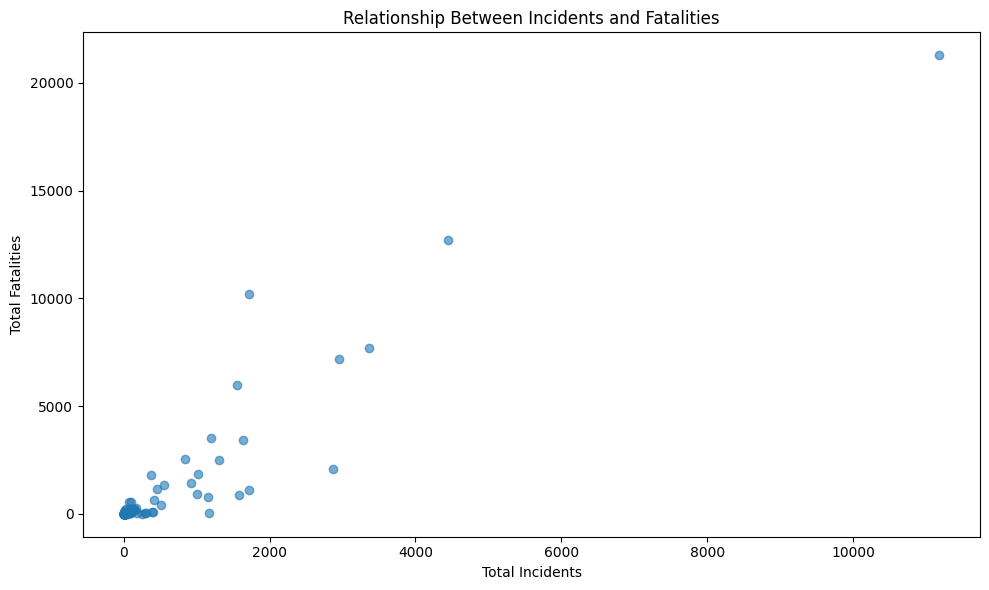


Correlation Matrix:
                rank     score  incidents  fatalities  injuries  hostages  \
rank        1.000000 -0.982835  -0.436759   -0.394951 -0.335228 -0.225102   
score      -0.982835  1.000000   0.516868    0.479365  0.410757  0.263119   
incidents  -0.436759  0.516868   1.000000    0.860467  0.863206  0.282083   
fatalities -0.394951  0.479365   0.860467    1.000000  0.912888  0.318144   
injuries   -0.335228  0.410757   0.863206    0.912888  1.000000  0.317053   
hostages   -0.225102  0.263119   0.282083    0.318144  0.317053  1.000000   
year       -0.044911 -0.018468   0.008191   -0.029836 -0.058075  0.031920   

                year  
rank       -0.044911  
score      -0.018468  
incidents   0.008191  
fatalities -0.029836  
injuries   -0.058075  
hostages    0.031920  
year        1.000000  

YEAR WITH HIGHEST INCIDENTS
Year: 2021
Incidents: 5,443

YEAR WITH HIGHEST FATALITIES
Year: 2015
Fatalities: 10,881

MOST AFFECTED COUNTRY
Country: Iraq
Total Incidents: 11,183


In [1]:
# ============================================================
# EXPLORING GLOBAL TERRORISM PATTERNS & TRENDS
# DATA ANALYTICS PROJECT
# ============================================================

# ---------------------------
# 1. IMPORT LIBRARIES
# ---------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------
# 2. LOAD DATASET
# ---------------------------

file_path = "1776311688-P5-Exploring Global Terrorism Patterns & Trends.xlsx"

df = pd.read_excel(file_path)

print("Dataset Loaded Successfully!")
print("\nFirst 5 Rows:")
print(df.head())


# ---------------------------
# 3. DATASET INFORMATION
# ---------------------------

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nDataset Information:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


# ---------------------------
# 4. DATA CLEANING
# ---------------------------

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Remove completely empty columns
df.dropna(axis=1, how="all", inplace=True)

# Convert column names to clean format
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("\nCleaned Column Names:")
print(df.columns.tolist())


# ---------------------------
# 5. BASIC STATISTICS
# ---------------------------

print("\nStatistical Summary:")
print(df.describe(include="all"))


# ---------------------------
# 6. IDENTIFY IMPORTANT COLUMNS
# ---------------------------

print("\nAvailable Columns:")
for column in df.columns:
    print(column)


# ============================================================
# IMPORTANT:
# Update the column names below if your dataset uses
# slightly different names.
# ============================================================

# Example expected columns:
# year
# country
# incidents
# fatalities
# injuries
# hostages


# ---------------------------
# 7. TOTAL KPI ANALYSIS
# ---------------------------

print("\n==============================")
print("GLOBAL TERRORISM KPIs")
print("==============================")

total_incidents = df["incidents"].sum()
total_fatalities = df["fatalities"].sum()
total_injuries = df["injuries"].sum()
total_hostages = df["hostages"].sum()

print(f"Total Incidents: {total_incidents:,.0f}")
print(f"Total Fatalities: {total_fatalities:,.0f}")
print(f"Total Injuries: {total_injuries:,.0f}")
print(f"Total Hostages: {total_hostages:,.0f}")


# ---------------------------
# 8. YEAR-WISE ANALYSIS
# ---------------------------

yearly_data = (
    df.groupby("year")
    .agg({
        "incidents": "sum",
        "fatalities": "sum",
        "injuries": "sum",
        "hostages": "sum"
    })
    .reset_index()
)

print("\nYear-wise Data:")
print(yearly_data)


# ---------------------------
# 9. TREND OF TERRORIST INCIDENTS
# ---------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_data["year"],
    yearly_data["incidents"],
    marker="o"
)

plt.title("Global Terrorism Incidents by Year")
plt.xlabel("Year")
plt.ylabel("Number of Incidents")
plt.xticks(rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()


# ---------------------------
# 10. FATALITIES & INJURIES TREND
# ---------------------------

plt.figure(figsize=(12, 6))

plt.plot(
    yearly_data["year"],
    yearly_data["fatalities"],
    marker="o",
    label="Fatalities"
)

plt.plot(
    yearly_data["year"],
    yearly_data["injuries"],
    marker="o",
    label="Injuries"
)

plt.title("Fatalities and Injuries Over Time")
plt.xlabel("Year")
plt.ylabel("Number of People")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# ---------------------------
# 11. TOP 10 COUNTRIES BY INCIDENTS
# ---------------------------

top_incident_countries = (
    df.groupby("country")["incidents"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Countries by Incidents:")
print(top_incident_countries)

plt.figure(figsize=(12, 6))

top_incident_countries.plot(
    kind="bar"
)

plt.title("Top 10 Countries by Terrorist Incidents")
plt.xlabel("Country")
plt.ylabel("Total Incidents")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ---------------------------
# 12. TOP 10 COUNTRIES BY FATALITIES
# ---------------------------

top_fatality_countries = (
    df.groupby("country")["fatalities"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Countries by Fatalities:")
print(top_fatality_countries)

plt.figure(figsize=(12, 6))

top_fatality_countries.plot(
    kind="bar"
)

plt.title("Top 10 Countries by Terrorism Fatalities")
plt.xlabel("Country")
plt.ylabel("Total Fatalities")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


# ---------------------------
# 13. TOP 10 COUNTRIES BY INJURIES
# ---------------------------

top_injury_countries = (
    df.groupby("country")["injuries"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Countries by Injuries:")
print(top_injury_countries)


# ---------------------------
# 14. CALCULATE FATALITY RATE
# ---------------------------

country_analysis = (
    df.groupby("country")
    .agg({
        "incidents": "sum",
        "fatalities": "sum",
        "injuries": "sum"
    })
    .reset_index()
)

country_analysis["fatality_rate"] = (
    country_analysis["fatalities"]
    / country_analysis["incidents"]
)

# Replace infinite values
country_analysis.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)

country_analysis = country_analysis.dropna(
    subset=["fatality_rate"]
)

print("\nCountries with Highest Fatality Rate:")

print(
    country_analysis
    .sort_values(
        by="fatality_rate",
        ascending=False
    )
    .head(10)
)


# ---------------------------
# 15. SCATTER PLOT
# INCIDENTS VS FATALITIES
# ---------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    country_analysis["incidents"],
    country_analysis["fatalities"],
    alpha=0.6
)

plt.title("Relationship Between Incidents and Fatalities")
plt.xlabel("Total Incidents")
plt.ylabel("Total Fatalities")

plt.tight_layout()
plt.show()


# ---------------------------
# 16. CORRELATION ANALYSIS
# ---------------------------

numeric_columns = df.select_dtypes(
    include=np.number
)

correlation = numeric_columns.corr()

print("\nCorrelation Matrix:")
print(correlation)


# ---------------------------
# 17. YEAR WITH MAXIMUM INCIDENTS
# ---------------------------

max_incident_year = yearly_data.loc[
    yearly_data["incidents"].idxmax()
]

print("\n==============================")
print("YEAR WITH HIGHEST INCIDENTS")
print("==============================")

print(
    f"Year: {int(max_incident_year['year'])}"
)

print(
    f"Incidents: {max_incident_year['incidents']:,.0f}"
)


# ---------------------------
# 18. YEAR WITH MAXIMUM FATALITIES
# ---------------------------

max_fatality_year = yearly_data.loc[
    yearly_data["fatalities"].idxmax()
]

print("\n==============================")
print("YEAR WITH HIGHEST FATALITIES")
print("==============================")

print(
    f"Year: {int(max_fatality_year['year'])}"
)

print(
    f"Fatalities: {max_fatality_year['fatalities']:,.0f}"
)


# ---------------------------
# 19. COUNTRY WITH MOST INCIDENTS
# ---------------------------

most_affected_country = (
    top_incident_countries.idxmax()
)

most_incidents = (
    top_incident_countries.max()
)

print("\n==============================")
print("MOST AFFECTED COUNTRY")
print("==============================")

print(f"Country: {most_affected_country}")

print(
    f"Total Incidents: {most_incidents:,.0f}"
)


# ---------------------------
# 20. COUNTRY WITH MOST FATALITIES
# ---------------------------

most_fatality_country = (
    top_fatality_countries.idxmax()
)

most_fatalities = (
    top_fatality_countries.max()
)

print("\n==============================")
print("COUNTRY WITH MOST FATALITIES")
print("==============================")

print(f"Country: {most_fatality_country}")

print(
    f"Total Fatalities: {most_fatalities:,.0f}"
)


# ---------------------------
# 21. EXPORT ANALYSIS RESULTS
# ---------------------------

with pd.ExcelWriter(
    "terrorism_analysis_results.xlsx"
) as writer:

    yearly_data.to_excel(
        writer,
        sheet_name="Yearly Analysis",
        index=False
    )

    country_analysis.to_excel(
        writer,
        sheet_name="Country Analysis",
        index=False
    )

    top_incident_countries.to_excel(
        writer,
        sheet_name="Top Incidents"
    )

    top_fatality_countries.to_excel(
        writer,
        sheet_name="Top Fatalities"
    )

print("\nAnalysis exported successfully!")


# ============================================================
# FINAL CONCLUSION
# ============================================================

print("\n==============================")
print("FINAL INSIGHTS")
print("==============================")

print("""
1. Analyze terrorism trends across different years.
2. Identify countries with the highest number of incidents.
3. Compare incidents with fatalities.
4. Identify countries with the highest terrorism severity.
5. Calculate fatality rates to understand attack intensity.
6. Study the relationship between incidents and casualties.
""")

In [13]:
# ============================================================
# GLOBAL TERRORISM DATA ANALYTICS
# SAVE ALL CHARTS AS IMAGES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt
import os

# ------------------------------------------------------------
# 1. LOAD DATA
# ------------------------------------------------------------

file_path = "1776311688-P5-Exploring Global Terrorism Patterns & Trends.xlsx"

df = pd.read_excel(file_path)

print("Dataset loaded successfully!")
print(df.head())


# ------------------------------------------------------------
# 2. CREATE IMAGE FOLDER
# ------------------------------------------------------------

image_folder = "images"

os.makedirs(image_folder, exist_ok=True)

print(f"Images will be saved in: {image_folder}")


# ------------------------------------------------------------
# 3. YEAR-WISE DATA
# ------------------------------------------------------------

yearly_data = (
    df.groupby("Year")
    .agg({
        "Incidents": "sum",
        "Fatalities": "sum",
        "Injuries": "sum",
        "Hostages": "sum"
    })
    .reset_index()
)


# ============================================================
# CHART 1: INCIDENTS BY YEAR
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_data["Year"],
    yearly_data["Incidents"],
    marker="o"
)

plt.title("Global Terrorism Incidents by Year")
plt.xlabel("Year")
plt.ylabel("Total Incidents")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(image_folder, "01_incidents_by_year.png"),
    dpi=300
)

plt.close()


# ============================================================
# CHART 2: FATALITIES BY YEAR
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_data["Year"],
    yearly_data["Fatalities"],
    marker="o"
)

plt.title("Global Terrorism Fatalities by Year")
plt.xlabel("Year")
plt.ylabel("Total Fatalities")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(image_folder, "02_fatalities_by_year.png"),
    dpi=300
)

plt.close()


# ============================================================
# CHART 3: INJURIES BY YEAR
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_data["Year"],
    yearly_data["Injuries"],
    marker="o"
)

plt.title("Global Terrorism Injuries by Year")
plt.xlabel("Year")
plt.ylabel("Total Injuries")
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(image_folder, "03_injuries_by_year.png"),
    dpi=300
)

plt.close()


# ============================================================
# CHART 4: INCIDENTS VS FATALITIES OVER TIME
# ============================================================

plt.figure(figsize=(10, 6))

plt.plot(
    yearly_data["Year"],
    yearly_data["Incidents"],
    marker="o",
    label="Incidents"
)

plt.plot(
    yearly_data["Year"],
    yearly_data["Fatalities"],
    marker="o",
    label="Fatalities"
)

plt.title("Incidents vs Fatalities Over Time")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(image_folder, "04_incidents_vs_fatalities.png"),
    dpi=300
)

plt.close()


# ============================================================
# CHART 5: TOP 10 COUNTRIES BY INCIDENTS
# ============================================================

top_incidents = (
    df.groupby("Country")["Incidents"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_incidents.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Terrorism Incidents")
plt.xlabel("Total Incidents")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    os.path.join(image_folder, "05_top_countries_incidents.png"),
    dpi=300
)

plt.close()


# ============================================================
# CHART 6: TOP 10 COUNTRIES BY FATALITIES
# ============================================================

top_fatalities = (
    df.groupby("Country")["Fatalities"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_fatalities.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Terrorism Fatalities")
plt.xlabel("Total Fatalities")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    os.path.join(image_folder, "06_top_countries_fatalities.png"),
    dpi=300
)

plt.close()


# ============================================================
# CHART 7: TOP 10 COUNTRIES BY INJURIES
# ============================================================

top_injuries = (
    df.groupby("Country")["Injuries"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_injuries.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Terrorism Injuries")
plt.xlabel("Total Injuries")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    os.path.join(image_folder, "07_top_countries_injuries.png"),
    dpi=300
)

plt.close()


# ============================================================
# CHART 8: TOP 10 COUNTRIES BY HOSTAGES
# ============================================================

top_hostages = (
    df.groupby("Country")["Hostages"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_hostages.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Hostages")
plt.xlabel("Total Hostages")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    os.path.join(image_folder, "08_top_countries_hostages.png"),
    dpi=300
)

plt.close()


# ============================================================
# CHART 9: INCIDENTS VS FATALITIES
# ============================================================

country_data = (
    df.groupby("Country")
    .agg({
        "Incidents": "sum",
        "Fatalities": "sum"
    })
    .reset_index()
)

plt.figure(figsize=(10, 6))

plt.scatter(
    country_data["Incidents"],
    country_data["Fatalities"],
    alpha=0.7
)

plt.title("Relationship Between Incidents and Fatalities")
plt.xlabel("Total Incidents")
plt.ylabel("Total Fatalities")

plt.tight_layout()

plt.savefig(
    os.path.join(image_folder, "09_incidents_vs_fatalities_scatter.png"),
    dpi=300
)

plt.close()


# ============================================================
# CHART 10: TOP 10 COUNTRIES BY SCORE
# ============================================================

top_score = (
    df.groupby("Country")["Score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 6))

top_score.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Countries by Average Terrorism Score")
plt.xlabel("Average Score")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    os.path.join(image_folder, "10_top_countries_score.png"),
    dpi=300
)

plt.close()


# ============================================================
# CHART 11: FATALITY RATE BY COUNTRY
# ============================================================

country_analysis = (
    df.groupby("Country")
    .agg({
        "Incidents": "sum",
        "Fatalities": "sum"
    })
    .reset_index()
)

country_analysis["Fatality Rate"] = (
    country_analysis["Fatalities"]
    / country_analysis["Incidents"]
)

# Remove countries with zero incidents
country_analysis = country_analysis.dropna()

top_fatality_rate = (
    country_analysis[
        country_analysis["Incidents"] >= 10
    ]
    .sort_values(
        by="Fatality Rate",
        ascending=False
    )
    .head(10)
)

plt.figure(figsize=(12, 6))

plt.barh(
    top_fatality_rate["Country"],
    top_fatality_rate["Fatality Rate"]
)

plt.title("Top Countries by Fatality Rate")
plt.xlabel("Fatalities per Incident")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    os.path.join(image_folder, "11_fatality_rate.png"),
    dpi=300
)

plt.close()


# ============================================================
# CHART 12: CORRELATION HEATMAP
# ============================================================

numeric_columns = [
    "Rank",
    "Score",
    "Incidents",
    "Fatalities",
    "Injuries",
    "Hostages"
]

correlation = df[numeric_columns].corr()

plt.figure(figsize=(10, 8))

plt.imshow(
    correlation,
    aspect="auto"
)

plt.colorbar()

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

# Add correlation values
for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):

        plt.text(
            j,
            i,
            round(correlation.iloc[i, j], 2),
            ha="center",
            va="center"
        )

plt.title("Correlation Between Terrorism Metrics")

plt.tight_layout()

plt.savefig(
    os.path.join(image_folder, "12_correlation_heatmap.png"),
    dpi=300
)

plt.close()


# ============================================================
# FINAL MESSAGE
# ============================================================

print("\n======================================")
print("ALL CHARTS SAVED SUCCESSFULLY!")
print("======================================")

print(f"\nTotal charts created: 12")
print(f"Folder location: {image_folder}")

Dataset loaded successfully!
  iso3c      Country  Rank     Score  Incidents  Fatalities  Injuries  \
0   IRQ         Iraq     1  9.599967       1288        2086      5050   
1   PAK     Pakistan     2  9.152620        638        1322      2297   
2   AFG  Afghanistan     3  9.134265        507        1511      2612   
3   SYR        Syria     4  8.238079        168        1014      1833   
4   YEM        Yemen     5  8.098513        219         651       798   

   Hostages  Year  
0        16  2012  
1       160  2012  
2        67  2012  
3        71  2012  
4       121  2012  
Images will be saved in: images

ALL CHARTS SAVED SUCCESSFULLY!

Total charts created: 12
Folder location: images


In [14]:
import shutil
from google.colab import files

shutil.make_archive("terrorism_charts", "zip", "images")

files.download("terrorism_charts.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>